# Session 1: Welcome to Digital Earth Sweden
**MOOC Series: From Satellite Data to Insights with Digital Earth Sweden**

---

## Session outline

- What is Digital Earth Sweden?
- A brief introduction to Earth observation and Sentinel-2
- Platform overview: user interface, API, and key resources
- Setting up your first Jupyter Notebook with the openEO API

By the end of this session you will have a working connection to the Digital Earth Sweden backend and be ready to load your first satellite image in Session 2.

---

## 1. What is Digital Earth Sweden?

**Digital Earth Sweden (DES)** is a workbench that makes Earth observation (EO) data accessible to researchers, public agencies, and developers across Sweden.

Key points:

- DES is developed by **RISE Research Institutes of Sweden** in collaboration with the Swedish National Space Agency (Rymdstyrelsen).
- The platform provides access to freely available satellite data, primarily from ESA (European Space Agency)'s **Copernicus** programme.
- Data is made available through open standards (openEO API, STAC, OGC WMS) so you can work with it from Python, QGIS, or a web browser.
- The platform is free to use for research and public-sector applications.

Official website: [https://digitalearth.se](https://digitalearth.se)

---

## 2. Introduction to Earth observation

**Earth observation** is the systematic collection of information about the Earth's surface and atmosphere using sensors on satellites, aircraft, and drones.

### Why satellites?

- They cover large areas repeatedly and consistently &mdash; the Sentinel-2 satellites have a swatch width of 290 km.
- Satellites revisit the same location every few days, enabling **monitoring** applications.
- They capture information beyond the visible spectrum, such as near-infrared (NIR), which is invisible to the human eye but highly informative for land cover analysis.

### Sentinel-2: the workhorse of this course

Sentinel-2 is a constellation of three satellites (Sentinel-2A, 2B, and 2C) operated by ESA as part of the Copernicus programme. Key facts:

| Property | Value |
|---|---|
| Spatial resolution | 10 m (visible + NIR), 20 m (red-edge, SWIR), 60 m (atmospheric) |
| Revisit time | \~5 days at the equator (\~3 days over Sweden) |
| Number of bands | 13 |
| Data access | Free and open |
| Archive start | 2015 (2018 on DES)|

The figure below shows the Sentinel-2 spectral bands with their respective spatial resolution:

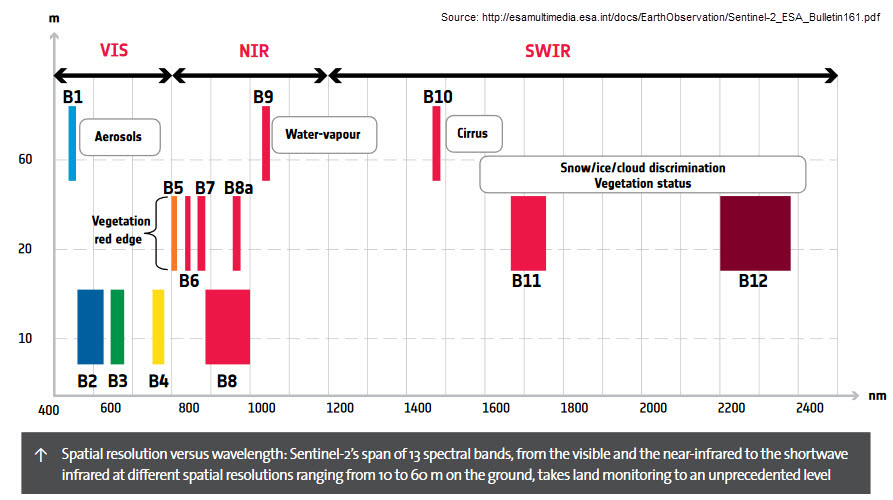

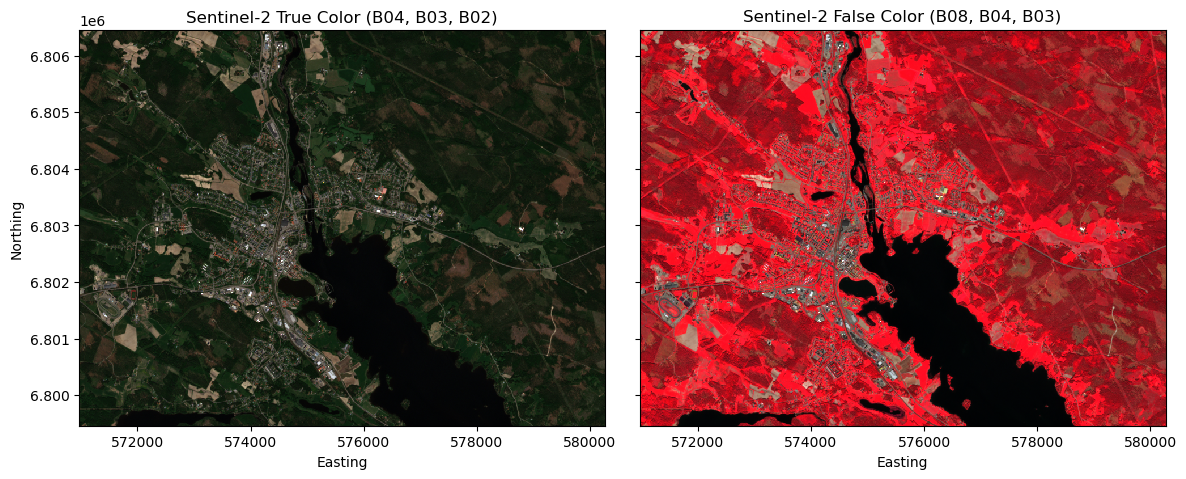

In [1]:
import openeo
import io
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

connection = openeo.connect('https://openeo.digitalearth.se')
connection.authenticate_basic(username='testuser', password='secretpassword')

aoi = {
    'west':  16.328473091125044,
    'east':  16.499276161193396,
    'south': 61.32281205270308,
    'north': 61.38375204609653,
    'crs':   'EPSG:4326',
}

image = connection.load_collection(
    collection_id='des_s2_msi_l2a',
    spatial_extent=aoi,
    temporal_extent=['2026-05-31', '2026-06-02'],
    bands=['B02', 'B03', 'B04', 'B08'],
).reduce_dimension(dimension='t', reducer='first')

image_tif = image.download(format='GTiff')

# Load into xarray
da = xr.open_dataarray(io.BytesIO(image_tif), engine='rasterio')
da = da.assign_coords(band=['B02', 'B03', 'B04', 'B08'])

# Rescale data
da = (da.astype(np.float32) / 10_000).clip(0, 1)

# Create different visualizations
true_color = da.sel(band=['B04', 'B03', 'B02'])
false_color = da.sel(band=['B08', 'B04', 'B03'])

fig, axs = plt.subplots(1, 2, figsize=(12, 10), sharey=True)
true_color.plot.imshow(rgb='band', vmin=0, vmax=0.4, ax=axs[0])
false_color.plot.imshow(rgb='band', vmin=0, vmax=0.4, ax=axs[1])
axs[0].set_aspect('equal')
axs[1].set_aspect('equal')
axs[0].set_title('Sentinel-2 True Color (B04, B03, B02)')
axs[1].set_title('Sentinel-2 False Color (B08, B04, B03)')
axs[0].set_xlabel('Easting')
axs[0].set_ylabel('Northing')
axs[1].set_xlabel('Easting')
axs[1].set_ylabel('')
plt.tight_layout()
plt.show()

---

## 3. Platform overview

Digital Earth Sweden can be accessed in several ways, including:

1. **Web interface** — A browser-based map explorer for searching and previewing satellite scenes. Available at [https://digitalearth.se](https://digitalearth.se).

2. **openEO API** — A standard Application Programming Interface (API) for processing EO data in the cloud. This is what we use in this course. The Python client (`openeo`) translates your Python code into backend processes that run on DES infrastructure.


### What is openEO?

openEO is an open standard for accessing and processing large EO datasets in a cloud environment. The key idea is:

- You write Python code **locally**.
- The openEO client translates your operations into a **process graph**.
- The process graph is sent to the **DES backend** for execution — data never leaves the server until you explicitly download a result.
- This means you can process large volumes of EO data without storing anything on your laptop.

---

## 4. Installing the openEO Python client

If you have not already installed the openEO Python package, run the cell below. In most Jupyter environments you only need to do this once.

In [2]:
# Install the openEO Python client (run once)
# %pip install openeo

## 5. Connecting to the Digital Earth Sweden backend

The first step in every openEO workflow is to establish a **connection** to the backend. The backend URL for Digital Earth Sweden is `https://openeo.digitalearth.se`.

After connecting, we authenticate with a username and password. For this course you can use the shared test credentials below. In a production setting you would use your own account.

In [3]:
import openeo

# Connect to the Digital Earth Sweden openEO backend
connection = openeo.connect('https://openeo.digitalearth.se')

# Authenticate with basic credentials
connection.authenticate_basic(username='testuser', password='secretpassword')

print('Connected to:', connection.describe_account())

Connected to: {'username': 'testuser', 'provider_id': 0, 'fullname': 'Test user', 'default_plan': 'Free', 'scopes': 'user storage', 'links': None}


## 6. Exploring what is available on the platform

Once connected, you can ask the backend which datasets (**collections**) are available. A collection is a large, time-series dataset containing satellite imagery or derived products.

In openEO, a collection is identified by a unique string ID such as `s2_msi_l2a` (Sentinel-2 Level-2A surface reflectance). We will use this collection throughout the course.

In [4]:
# List all available collection IDs on Digital Earth Sweden
collection_ids = connection.list_collection_ids()
print('Collections:')
for cid in collection_ids:
    print(' -', cid)

Collections:
 - des_s2_msi_l2a
 - NMD_2018_Basskikt_v1_1
 - NMD_2018_Produktivitet_v1_1
 - s2_msi_l1c
 - s2_msi_l2a


In [5]:
# Inspect the metadata for the Sentinel-2 Level-2A collection
s2_info = connection.describe_collection('s2_msi_l2a')

print('Title      :', s2_info.get('title', 'N/A'))
print('Description:', s2_info.get('description', 'N/A')[:200], '...')
print('Spatial ext:', s2_info.get('extent', {}).get('spatial', 'N/A'))
print('Temporal ext:', s2_info.get('extent', {}).get('temporal', 'N/A'))

Title      : s2_msi_l2a
Description: Sentinel-2 MSI L2A Cloud-Optimized GeoTIFFs ...
Spatial ext: {'bbox': [[-180.00000000000003, 53.0712565262867, 179.52076997156803, 72.09958113071337]]}
Temporal ext: {'interval': [['2018-03-01T10:30:19.027000Z', '2026-07-12T10:26:01.025000Z']]}


## 7. Checking available processes

In addition to collections, the backend exposes a set of **processes** — built-in operations you can apply to your data (e.g. computing NDVI, reducing a time dimension, masking clouds). You can list them to discover what is supported.

In [6]:
# List all available processes on the DES backend
processes = connection.list_processes()
process_names = [p['id'] for p in processes]
print(f'Total processes available: {len(process_names)}')
print('\nA selection of processes:')
selected = ['ndvi', 'mask', 'reduce_dimension', 'load_collection', 'save_result']
for name in selected:
    if name in process_names:
        print(f'  ✓ {name}')
    else:
        print(f'  ✗ {name} (not found)')

Total processes available: 98

A selection of processes:
  ✓ ndvi
  ✓ mask
  ✓ reduce_dimension
  ✓ load_collection
  ✓ save_result


## Summary

In this session you:

- Learned what Digital Earth Sweden is and why it exists.
- Got an overview of Sentinel-2 and its key spectral bands.
- Understood the openEO model: local Python → process graph → backend execution.
- Established a working connection to the DES backend.
- Explored available collections and processes.

**Next session:** we will load your first Sentinel-2 scene, create a datacube, and visualise a satellite image for the first time.

---
*Digital Earth Sweden MOOC — Session 1 of 6*